In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent
NAB_ROOT = PROJECT_ROOT / "data" / "raw" / "NAB"
DATA_DIR = NAB_ROOT / "data"
LABELS_FILE = NAB_ROOT / "labels" / "combined_windows.json"

# Sanity check
assert DATA_DIR.exists(), f"NAB data folder not found at {DATA_DIR}"
assert LABELS_FILE.exists(), f"Labels file not found at {LABELS_FILE}"

print(f"NAB data root: {DATA_DIR}")
print(f"Labels file:   {LABELS_FILE}")

NAB data root: D:\dissertation\data\raw\NAB\data
Labels file:   D:\dissertation\data\raw\NAB\labels\combined_windows.json


In [2]:
with open(LABELS_FILE) as f:
    labels = json.load(f)

print(f"Total labelled files: {len(labels)}")
print()
print("First few entries:")
for path, windows in list(labels.items())[:5]:
    print(f"  {path}")
    print(f"    {len(windows)} anomaly window(s)")

Total labelled files: 58

First few entries:
  artificialNoAnomaly/art_daily_no_noise.csv
    0 anomaly window(s)
  artificialNoAnomaly/art_daily_perfect_square_wave.csv
    0 anomaly window(s)
  artificialNoAnomaly/art_daily_small_noise.csv
    0 anomaly window(s)
  artificialNoAnomaly/art_flatline.csv
    0 anomaly window(s)
  artificialNoAnomaly/art_noisy.csv
    0 anomaly window(s)


In [3]:
from collections import defaultdict

# Group files by category (the subfolder name before the slash)
by_category = defaultdict(list)
for path, windows in labels.items():
    category = path.split("/")[0]
    by_category[category].append((path, len(windows)))

# Summary per category
print(f"{'Category':<25} {'Files':>6} {'With anomalies':>15} {'Total windows':>15}")
print("-" * 65)
for category, files in sorted(by_category.items()):
    with_anomalies = sum(1 for _, n in files if n > 0)
    total_windows = sum(n for _, n in files)
    print(f"{category:<25} {len(files):>6} {with_anomalies:>15} {total_windows:>15}")

Category                   Files  With anomalies   Total windows
-----------------------------------------------------------------
artificialNoAnomaly            5               0               0
artificialWithAnomaly          6               6               6
realAWSCloudwatch             17              16              30
realAdExchange                 6               6              14
realKnownCause                 7               7              19
realTraffic                    7               7              14
realTweets                    10              10              33


In [4]:
print("realKnownCause files:")
for path, windows in labels.items():
    if path.startswith("realKnownCause/"):
        filename = path.split("/")[-1]
        print(f"  {filename:<50} {len(windows)} window(s)")

realKnownCause files:
  ambient_temperature_system_failure.csv             2 window(s)
  cpu_utilization_asg_misconfiguration.csv           1 window(s)
  ec2_request_latency_system_failure.csv             3 window(s)
  machine_temperature_system_failure.csv             4 window(s)
  nyc_taxi.csv                                       5 window(s)
  rogue_agent_key_hold.csv                           2 window(s)
  rogue_agent_key_updown.csv                         2 window(s)


In [5]:
# Load the primary case study file
target_file = "realKnownCause/machine_temperature_system_failure.csv"
csv_path = DATA_DIR / target_file

df = pd.read_csv(csv_path, parse_dates=["timestamp"])

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {df['timestamp'].max() - df['timestamp'].min()}")
print()
print("First 5 rows:")
print(df.head())
print()
print("Value statistics:")
print(df['value'].describe())

Shape: (22695, 2)
Columns: ['timestamp', 'value']
Time range: 2013-12-02 21:15:00 to 2014-02-19 15:25:00
Duration: 78 days 18:10:00

First 5 rows:
            timestamp      value
0 2013-12-02 21:15:00  73.967322
1 2013-12-02 21:20:00  74.935882
2 2013-12-02 21:25:00  76.124162
3 2013-12-02 21:30:00  78.140707
4 2013-12-02 21:35:00  79.329836

Value statistics:
count    22695.000000
mean        85.926498
std         13.746912
min          2.084721
25%         83.080078
50%         89.408246
75%         94.016252
max        108.510543
Name: value, dtype: float64


In [6]:
# Check sampling regularity
time_diffs = df['timestamp'].diff()

print(f"Median interval: {time_diffs.median()}")
print(f"Min interval:    {time_diffs.min()}")
print(f"Max interval:    {time_diffs.max()}")
print()
print(f"Number of intervals != 5 minutes: {(time_diffs != pd.Timedelta(minutes=5)).sum() - 1}")
# The -1 accounts for the first row, which has NaT (no previous row to diff against)

# If there are irregular intervals, show them
irregular = df[time_diffs != pd.Timedelta(minutes=5)].iloc[1:]  # skip first NaT row
if len(irregular) > 0:
    print(f"\nFirst few irregular intervals:")
    for idx in irregular.head().index:
        prev_time = df['timestamp'].iloc[idx-1]
        curr_time = df['timestamp'].iloc[idx]
        gap = curr_time - prev_time
        print(f"  Row {idx}: {prev_time} -> {curr_time} (gap: {gap})")

Median interval: 0 days 00:05:00
Min interval:    -1 days +23:05:00
Max interval:    0 days 00:05:00

Number of intervals != 5 minutes: 1

First few irregular intervals:
  Row 10149: 2014-01-07 02:55:00 -> 2014-01-07 02:00:00 (gap: -1 days +23:05:00)


Anomaly windows for realKnownCause/machine_temperature_system_failure.csv:
  2013-12-10 06:25:00.000000  ->  2013-12-12 05:35:00.000000
  2013-12-15 17:50:00.000000  ->  2013-12-17 17:00:00.000000
  2014-01-27 14:20:00.000000  ->  2014-01-29 13:30:00.000000
  2014-02-07 14:55:00.000000  ->  2014-02-09 14:05:00.000000



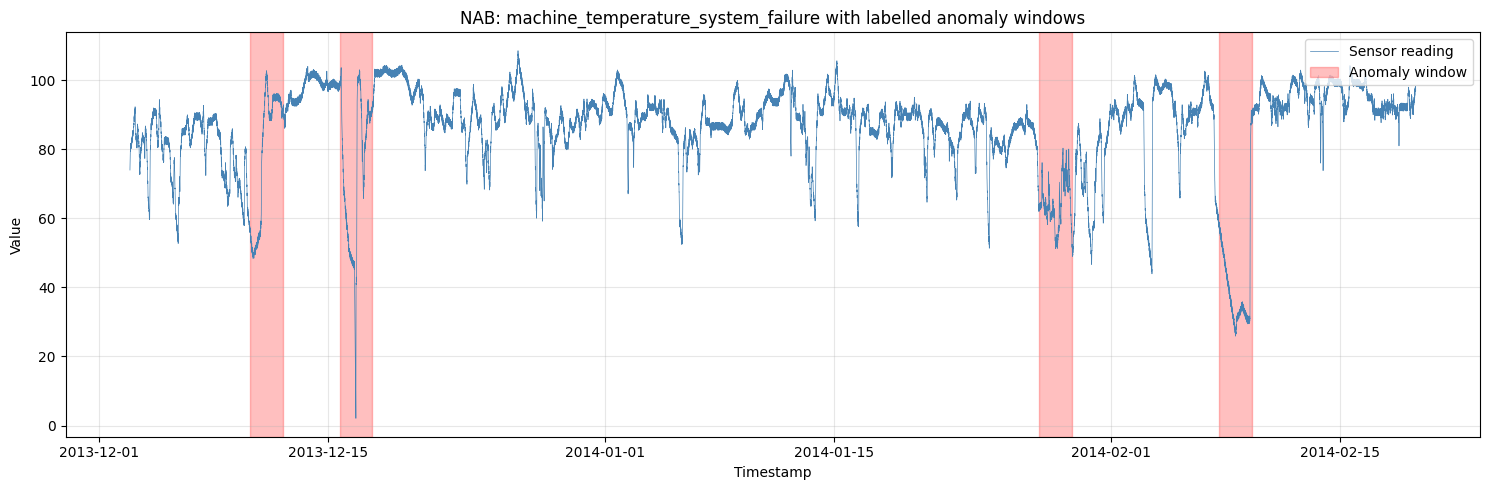

In [7]:
# Get the anomaly windows for this file
anomaly_windows = labels[target_file]
print(f"Anomaly windows for {target_file}:")
for start, end in anomaly_windows:
    print(f"  {start}  ->  {end}")
print()

# Convert window timestamps from strings to pandas datetimes
anomaly_windows_dt = [
    (pd.to_datetime(start), pd.to_datetime(end))
    for start, end in anomaly_windows
]

# Plot the time series
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['timestamp'], df['value'], linewidth=0.5, color='steelblue', label='Sensor reading')

# Shade anomaly windows in red
for start, end in anomaly_windows_dt:
    ax.axvspan(start, end, color='red', alpha=0.25, label='Anomaly window')

# Avoid duplicate legend entries for the shaded regions
handles, lbls = ax.get_legend_handles_labels()
by_label = dict(zip(lbls, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.set_xlabel('Timestamp')
ax.set_ylabel('Value')
ax.set_title('NAB: machine_temperature_system_failure with labelled anomaly windows')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

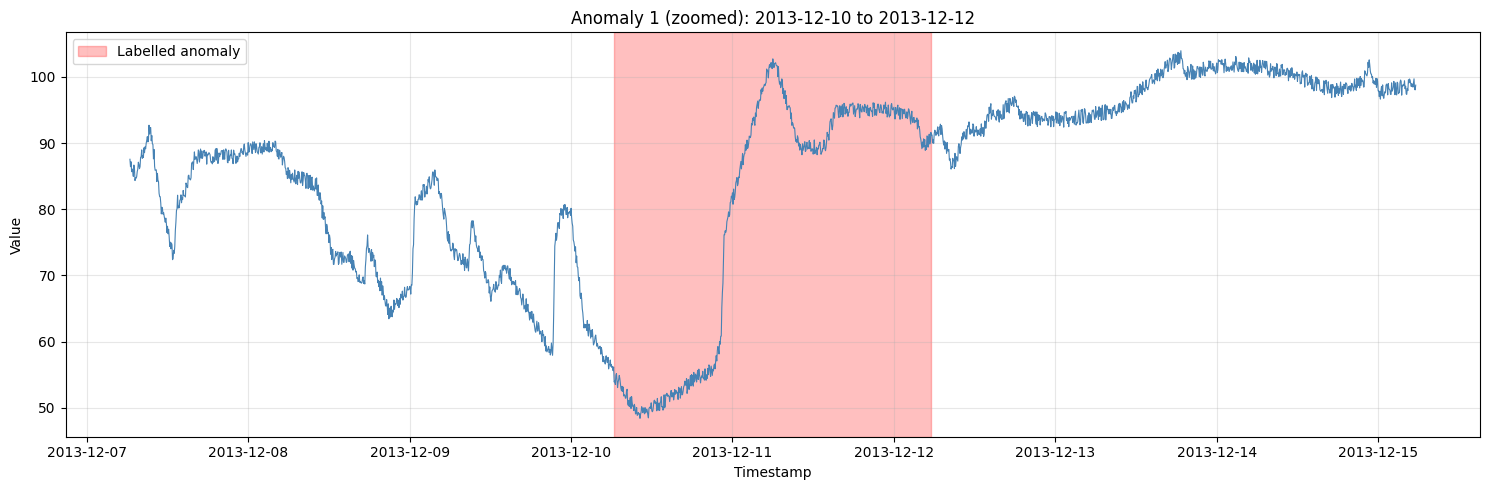

Anomaly window: 2013-12-10 06:25:00 to 2013-12-12 05:35:00
Window duration: 1 days 23:10:00
Readings inside window: 567


In [8]:
# Zoom in on the first anomaly window with some surrounding context
start, end = anomaly_windows_dt[0]
margin = pd.Timedelta(days=3)  # show 3 days before and after

view_start = start - margin
view_end = end + margin

mask = (df['timestamp'] >= view_start) & (df['timestamp'] <= view_end)
df_zoom = df.loc[mask]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_zoom['timestamp'], df_zoom['value'], linewidth=0.8, color='steelblue')
ax.axvspan(start, end, color='red', alpha=0.25, label='Labelled anomaly')

ax.set_xlabel('Timestamp')
ax.set_ylabel('Value')
ax.set_title(f'Anomaly 1 (zoomed): {start.date()} to {end.date()}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Anomaly window: {start} to {end}")
print(f"Window duration: {end - start}")
print(f"Readings inside window: {((df['timestamp'] >= start) & (df['timestamp'] <= end)).sum()}")

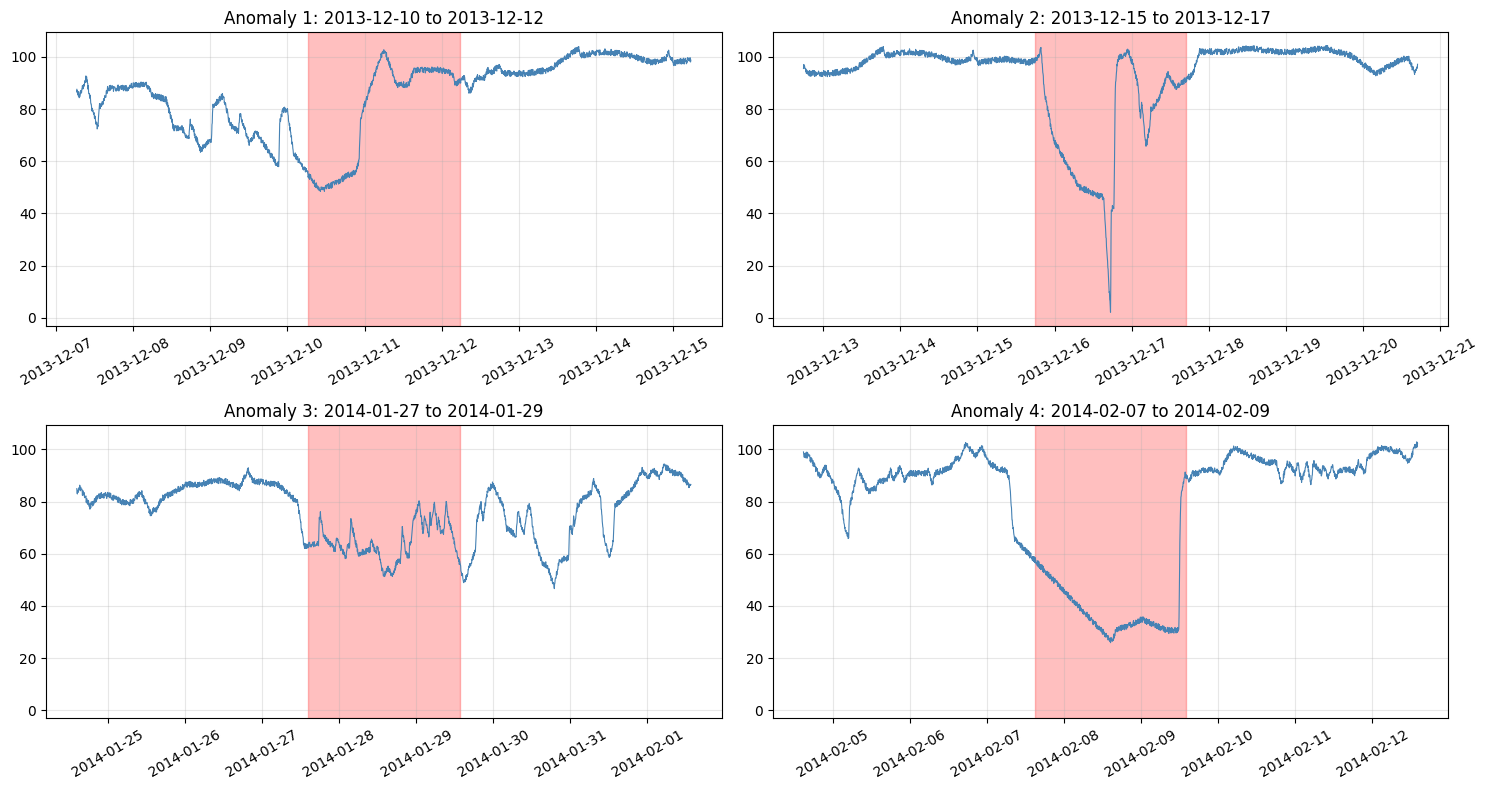

In [9]:
# Plot all four anomaly windows in a 2x2 grid for comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()

margin = pd.Timedelta(days=3)

for i, (start, end) in enumerate(anomaly_windows_dt):
    view_start = start - margin
    view_end = end + margin
    mask = (df['timestamp'] >= view_start) & (df['timestamp'] <= view_end)
    df_zoom = df.loc[mask]

    ax = axes[i]
    ax.plot(df_zoom['timestamp'], df_zoom['value'], linewidth=0.8, color='steelblue')
    ax.axvspan(start, end, color='red', alpha=0.25)
    ax.set_title(f'Anomaly {i+1}: {start.date()} to {end.date()}')
    ax.grid(True, alpha=0.3)

    # Rotate x-axis labels so they don't overlap
    ax.tick_params(axis='x', rotation=30)

# Shared y-axis across all subplots for fair comparison
y_min = min(ax.get_ylim()[0] for ax in axes)
y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

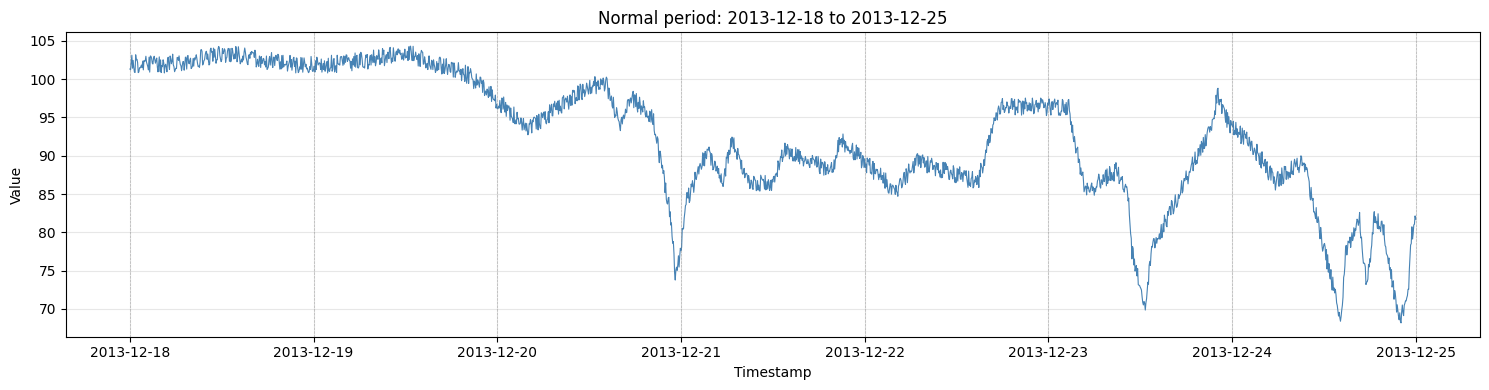

Normal period stats:
count    2017.000000
mean       92.453540
std         8.419020
min        68.180595
25%        87.349555
50%        92.760632
75%       100.919270
max       104.309799
Name: value, dtype: float64


In [10]:
# Pick a stretch of clearly-normal data: a week with no labelled anomalies
# Looking at the full plot, late December (Dec 18-25) is clean
normal_start = pd.Timestamp('2013-12-18')
normal_end = pd.Timestamp('2013-12-25')

mask = (df['timestamp'] >= normal_start) & (df['timestamp'] <= normal_end)
df_normal = df.loc[mask]

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df_normal['timestamp'], df_normal['value'], linewidth=0.8, color='steelblue')
ax.set_title(f'Normal period: {normal_start.date()} to {normal_end.date()}')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)

# Mark midnight boundaries to see if there's a daily pattern
for day in pd.date_range(normal_start, normal_end, freq='D'):
    ax.axvline(day, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Normal period stats:")
print(df_normal['value'].describe())